# LANDER vs SA-LANDER on Medical Imaging (OrganAMNIST)

## Fair Head-to-Head Comparison on Identical Budget

**Dataset:** OrganAMNIST (11 organ classes from CT scans, ~58K images)

**Why this dataset:**
- 11 classes → 3 tasks (4, 4, 3 classes) — enough for meaningful FCIL
- Class names are everyday English: heart, liver, lung, kidney — CLIP understands these
- Medical imaging is a real-world federated scenario (hospitals can't share patient CT scans)

**Both methods run with identical budget.** Any difference is purely from the adaptive radius.


In [1]:
# ============================================================
# Cell: Install Dependencies
# ============================================================
import subprocess, sys, os
def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
install("transformers")
install("medmnist")
try:
    from kaggle_secrets import UserSecretsClient
    secrets = UserSecretsClient()
    hf_token = secrets.get_secret("HF_TOKEN")
    os.environ["HF_TOKEN"] = hf_token
    from huggingface_hub import login
    login(token=hf_token, add_to_git_credential=False)
    print("HuggingFace authenticated.")
except: print("HF auth skipped.")
print("Done.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 3.9 MB/s eta 0:00:00


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HuggingFace authenticated.
Done.


In [2]:
# ============================================================
# Cell: Imports & Configuration
# ============================================================
import os, copy, math, time, random, warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import logging
logging.getLogger("transformers.modeling_utils").setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

SEED = 2023
def setup_seed(seed):
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
    np.random.seed(seed); random.seed(seed)
    torch.backends.cudnn.deterministic = True
setup_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---- Config: same budget for BOTH methods ----
CFG = dict(
    num_classes    = 11,
    num_tasks      = 3,
    task_splits    = [4, 4, 3],      # classes per task
    num_clients    = 3,
    beta           = 0.5,
    com_rounds     = 30,
    local_epochs   = 2,
    local_bs       = 64,
    local_lr       = 0.04,
    weight_decay   = 5e-4,
    syn_rounds     = 15,
    g_steps        = 20,
    warmup         = 3,
    lr_g           = 2e-3,
    syn_batch_size = 64,
    syn_total      = 3000,
    bn_weight      = 1.0,
    oh_weight      = 0.5,
    adv_weight     = 1.0,
    ltc_weight     = 5.0,
    kd_temperature = 2.0,
    alpha_cur_base = 0.2,
    alpha_pre_base = 0.4,
    lte_dim        = 512,
    feature_dim    = 512,
    nz             = 256,
    lander_r       = 0.015,
    sa_r_min       = 0.005,
    sa_r_max       = 0.05,
    sa_r_momentum  = 0.9,
    img_size       = 28,
    img_channels   = 3,
    seed           = SEED,
)
print("Tasks:", CFG['num_tasks'], "| Splits:", CFG['task_splits'],
      "| Clients:", CFG['num_clients'], "| Rounds:", CFG['com_rounds'])


Device: cuda
Tasks: 3 | Splits: [4, 4, 3] | Clients: 3 | Rounds: 30


In [3]:
# ============================================================
# Cell: Load OrganAMNIST + CLIP Embeddings
# ============================================================
from medmnist import OrganAMNIST
import medmnist

info = medmnist.INFO['organamnist']
CLASS_NAMES = [info['label'][str(i)] for i in range(11)]
print("Classes:", CLASS_NAMES)

# CLIP text embeddings for organ names
def compute_clip_embeddings(names):
    try:
        from transformers import CLIPTokenizer, CLIPTextModel
        print("Loading CLIP...")
        tok = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
        model = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
        model.eval()
        prompts = [f"a CT scan of a {n.replace('-', ' ').replace('_', ' ')}" for n in names]
        print("Prompts:", prompts)
        embs = []
        with torch.no_grad():
            for p in prompts:
                t = tok(p, return_tensors="pt", padding=True, truncation=True)
                embs.append(model(**t).pooler_output.squeeze(0))
        embs = F.normalize(torch.stack(embs), dim=-1)
        print("CLIP embeddings:", embs.shape)
        return embs
    except Exception as e:
        print(f"CLIP failed ({e}), using random.")
        torch.manual_seed(42)
        return F.normalize(torch.randn(len(names), 512), dim=-1)

LTE_EMBEDDINGS = compute_clip_embeddings(CLASS_NAMES)

# ---- Load dataset ----
# OrganAMNIST is 28x28 grayscale; convert to 3-channel
DATA_MEAN = (0.5,)
DATA_STD  = (0.5,)
NORM_MEAN = (0.5, 0.5, 0.5)
NORM_STD  = (0.5, 0.5, 0.5)

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomCrop(28, padding=2),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])
test_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(NORM_MEAN, NORM_STD),
])

train_data = OrganAMNIST(split='train', transform=train_tf, download=True, size=28)
test_data  = OrganAMNIST(split='test',  transform=test_tf,  download=True, size=28)

train_labels = train_data.labels.squeeze().astype(int)
test_labels  = test_data.labels.squeeze().astype(int)
print(f"Train: {len(train_labels)}, Test: {len(test_labels)}")
print("Label distribution:", {i: (train_labels==i).sum() for i in range(11)})

# Class order: shuffle
np.random.seed(SEED)
class_order = np.random.permutation(11).tolist()
label_map = {orig: new for new, orig in enumerate(class_order)}
train_labels_mapped = np.array([label_map[l] for l in train_labels])
test_labels_mapped  = np.array([label_map[l] for l in test_labels])
LTE_ORDERED = LTE_EMBEDDINGS[class_order].to(DEVICE)
print("Class order:", class_order)
print("Mapped names:", [CLASS_NAMES[c] for c in class_order])


Classes: ['bladder', 'femur-left', 'femur-right', 'heart', 'kidney-left', 'kidney-right', 'liver', 'lung-left', 'lung-right', 'pancreas', 'spleen']
Loading CLIP...


tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

The following layers were not sharded: text_model.encoder.layers.*.self_attn.v_proj.bias, text_model.embeddings.position_embedding.weight, text_model.final_layer_norm.bias, text_model.encoder.layers.*.layer_norm2.bias, text_model.encoder.layers.*.layer_norm2.weight, text_model.encoder.layers.*.layer_norm1.weight, text_model.encoder.layers.*.self_attn.k_proj.weight, text_model.encoder.layers.*.self_attn.out_proj.bias, text_model.encoder.layers.*.self_attn.q_proj.weight, text_model.embeddings.token_embedding.weight, text_model.encoder.layers.*.layer_norm1.bias, text_model.encoder.layers.*.self_attn.out_proj.weight, text_model.encoder.layers.*.mlp.fc2.weight, text_model.encoder.layers.*.mlp.fc2.bias, text_model.encoder.layers.*.self_attn.k_proj.bias, text_model.encoder.layers.*.self_attn.v_proj.weight, text_model.encoder.layers.*.mlp.fc1.weight, text_model.encoder.layers.*.mlp.fc1.bias, text_model.encoder.layers.*.self_attn.q_proj.bias, text_model.final_layer_norm.weight


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Prompts: ['a CT scan of a bladder', 'a CT scan of a femur left', 'a CT scan of a femur right', 'a CT scan of a heart', 'a CT scan of a kidney left', 'a CT scan of a kidney right', 'a CT scan of a liver', 'a CT scan of a lung left', 'a CT scan of a lung right', 'a CT scan of a pancreas', 'a CT scan of a spleen']
CLIP embeddings: torch.Size([11, 512])


100%|██████████| 38.2M/38.2M [00:03<00:00, 12.2MB/s]


Train: 34561, Test: 17778
Label distribution: {0: np.int64(1956), 1: np.int64(1390), 2: np.int64(1357), 3: np.int64(1474), 4: np.int64(3963), 5: np.int64(3817), 6: np.int64(6164), 7: np.int64(3919), 8: np.int64(3929), 9: np.int64(3031), 10: np.int64(3561)}
Class order: [8, 2, 5, 0, 3, 4, 1, 10, 6, 9, 7]
Mapped names: ['lung-right', 'femur-right', 'kidney-right', 'bladder', 'heart', 'kidney-left', 'femur-left', 'spleen', 'liver', 'pancreas', 'lung-left']


In [4]:
# ============================================================
# Cell: Dataset Utilities
# ============================================================
def partition_data_dirichlet(labels, beta, n_parties, task_classes):
    mask = np.isin(labels, task_classes)
    task_indices = np.where(mask)[0]
    task_labels = labels[task_indices]
    if beta == 0:
        np.random.shuffle(task_indices)
        splits = np.array_split(task_indices, n_parties)
        return {i: splits[i].tolist() for i in range(n_parties)}
    min_size = 0
    while min_size < 2:
        idx_batch = [[] for _ in range(n_parties)]
        for k in task_classes:
            idx_k = task_indices[task_labels == k]
            np.random.shuffle(idx_k)
            props = np.random.dirichlet(np.repeat(beta, n_parties))
            props = (np.cumsum(props) * len(idx_k)).astype(int)[:-1]
            for j, sp in enumerate(np.split(idx_k, props)):
                idx_batch[j].extend(sp.tolist())
        min_size = min(len(x) for x in idx_batch)
    for j in range(n_parties): np.random.shuffle(idx_batch[j])
    return {j: idx_batch[j] for j in range(n_parties)}

class IndexedDataset(Dataset):
    def __init__(self, base, indices, labels):
        self.base, self.indices, self.labels = base, indices, labels
    def __len__(self): return len(self.indices)
    def __getitem__(self, idx):
        i = self.indices[idx]
        img, _ = self.base[i]
        return idx, img, torch.tensor(self.labels[i], dtype=torch.long)

class SimpleImageDataset(Dataset):
    def __init__(self, images):
        self.images = images
        self.normalize = transforms.Normalize(NORM_MEAN, NORM_STD)
        self.augment = transforms.Compose([
            transforms.RandomCrop(28, padding=2),
            transforms.RandomHorizontalFlip(),
        ])
    def __len__(self): return len(self.images)
    def __getitem__(self, idx):
        img = self.images[idx]
        img = self.augment(img)
        img = self.normalize(img)
        return img

print("Utilities ready.")


Utilities ready.


In [5]:
# ============================================================
# Cell: Model (ResNet-18 adapted for 28x28)
# ============================================================
from torchvision.models import resnet18 as tv_resnet18

class IncrementalResNet(nn.Module):
    def __init__(self, feature_dim=512, lte_dim=512):
        super().__init__()
        backbone = tv_resnet18(weights=None)
        backbone.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        backbone.maxpool = nn.Identity()
        self.feature_dim = backbone.fc.in_features
        backbone.fc = nn.Identity()
        self.backbone = backbone
        self.mapping = nn.Linear(self.feature_dim, lte_dim)
        self.fc = None

    def update_fc(self, n):
        device = next(self.backbone.parameters()).device
        new_fc = nn.Linear(self.feature_dim, n)
        nn.init.kaiming_uniform_(new_fc.weight, nonlinearity='linear')
        nn.init.constant_(new_fc.bias, 0)
        if self.fc is not None:
            old = self.fc.out_features
            new_fc.weight.data[:old] = self.fc.weight.data.cpu().clone()
            new_fc.bias.data[:old]   = self.fc.bias.data.cpu().clone()
        self.fc = new_fc.to(device)

    def forward(self, x):
        f = self.backbone(x)
        att = self.mapping(f)
        logits = self.fc(f) if self.fc is not None else None
        return {'logits': logits, 'features': f, 'att': att}

    def copy(self): return copy.deepcopy(self)
    def freeze(self):
        for p in self.parameters(): p.requires_grad = False
        self.eval(); return self

_m = IncrementalResNet().to(DEVICE); _m.update_fc(4)
_o = _m(torch.randn(2, 3, 28, 28, device=DEVICE))
print("Model OK:", _o['logits'].shape, _o['att'].shape)
del _m, _o; torch.cuda.empty_cache()


Model OK: torch.Size([2, 4]) torch.Size([2, 512])


In [6]:
# ============================================================
# Cell: Generator (adapted for 28x28)
# ============================================================
class NoisyLayerGenerator(nn.Module):
    def __init__(self, label_emb, ngf=64, img_size=28, nc=3,
                 nl=10, le_emb_size=256, le_size=512, sbz=64):
        super().__init__()
        self.label_emb = nn.Parameter(label_emb, requires_grad=False)
        self.init_size = max(img_size // 4, 1)
        self.nl, self.nle = nl, int(np.ceil(sbz / nl))
        self.n1 = nn.BatchNorm1d(le_size)
        self.le1 = nn.ModuleList([nn.Linear(le_size, le_emb_size) for _ in range(self.nle)])
        self.l1 = nn.Sequential(nn.Linear(le_emb_size, ngf * 2 * self.init_size ** 2))
        # Upsample 7->14->28
        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(ngf*2), nn.Upsample(scale_factor=2),
            nn.Conv2d(ngf*2, ngf*2, 3, 1, 1, bias=False), nn.BatchNorm2d(ngf*2), nn.LeakyReLU(0.2, True),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(ngf*2, ngf, 3, 1, 1, bias=False), nn.BatchNorm2d(ngf), nn.LeakyReLU(0.2, True),
            nn.Conv2d(ngf, nc, 3, 1, 1), nn.Sigmoid())

    def forward(self, targets):
        le = self.n1(self.label_emb[targets])
        v = None
        for i in range(self.nle):
            s, e = i*self.nl, min((i+1)*self.nl, le.shape[0])
            sv = self.le1[i](le[s:e])
            v = sv if v is None else torch.cat((v, sv))
        out = self.l1(v).view(v.shape[0], -1, self.init_size, self.init_size)
        return self.conv_blocks(out)

    def re_init_noisy_layer(self):
        for i in range(self.nle):
            nn.init.normal_(self.le1[i].weight, 0, 1)
            nn.init.constant_(self.le1[i].bias, 0)

print("Generator ready (28x28 output).")


Generator ready (28x28 output).


In [7]:
# ============================================================
# Cell: Loss Functions & Utilities
# ============================================================

class DeepInversionHook:
    def __init__(self, module):
        self.hook = module.register_forward_hook(self.hook_fn)
        self.r_feature = None
    def hook_fn(self, module, inp, out):
        nch = inp[0].shape[1]
        mean = inp[0].mean([0,2,3])
        var = inp[0].permute(1,0,2,3).contiguous().view([nch,-1]).var(1, unbiased=False)
        self.r_feature = torch.norm(module.running_var.data - var, 2) + \
                         torch.norm(module.running_mean.data - mean, 2)
    def remove(self): self.hook.remove()

class AdaptiveBoundingLoss:
    def __init__(self, num_classes, r_init=0.015, r_min=0.005, r_max=0.05, momentum=0.9):
        self.radii = torch.full((num_classes,), r_init)
        self.r_min, self.r_max, self.momentum = r_min, r_max, momentum
        self.initialized = torch.zeros(num_classes, dtype=torch.bool)
    def to(self, device):
        self.radii = self.radii.to(device)
        self.initialized = self.initialized.to(device)
        return self
    def __call__(self, features, targets_emb, labels):
        per_sample = ((features - targets_emb.detach())**2).mean(dim=-1)
        with torch.no_grad():
            for c in labels.unique():
                m = (labels == c)
                d = per_sample[m].mean()
                if not self.initialized[c]:
                    self.radii[c] = d.clamp(self.r_min, self.r_max)
                    self.initialized[c] = True
                else:
                    self.radii[c] = (self.momentum * self.radii[c] + (1 - self.momentum) * d).clamp(self.r_min, self.r_max)
        return torch.relu(per_sample - self.radii[labels]).mean()

def bounding_loss_fixed(features, targets_emb, r):
    return torch.relu(F.mse_loss(features, targets_emb.detach()) - r)

def kd_loss(s, t, T=2.0):
    return F.kl_div(F.log_softmax(s/T, 1), F.softmax(t/T, 1), reduction='batchmean') * T * T

def fedavg(ws):
    avg = copy.deepcopy(ws[0])
    for k in avg:
        for i in range(1, len(ws)): avg[k] = avg[k] + ws[i][k]
        if avg[k].is_floating_point(): avg[k] = avg[k] / len(ws)
        else: avg[k] = avg[k] // len(ws)
    return avg

print("Losses ready.")


Losses ready.


In [8]:
# ============================================================
# Cell: Data-Free Generator
# ============================================================
class DataFreeGenerator:
    def __init__(self, teacher, generator, num_classes, label_emb, cfg, adaptive_bl=None):
        self.teacher = teacher.eval()
        self.generator = generator.to(DEVICE).train()
        self.num_classes, self.label_emb, self.cfg = num_classes, label_emb, cfg
        self.adaptive_bl = adaptive_bl
        self.hooks = [DeepInversionHook(m) for m in teacher.modules() if isinstance(m, nn.BatchNorm2d)]
        self.student = copy.deepcopy(teacher)
        for p in self.student.parameters():
            if p.dim() >= 2: p.data.normal_(0, 0.01)
            else: p.data.zero_()
        self.mean = torch.tensor([0.5,0.5,0.5], requires_grad=True, device=DEVICE)
        self.std  = torch.tensor([0.2,0.2,0.2], requires_grad=True, device=DEVICE)

    def _make_targets(self, bs):
        s, v = bs // self.num_classes, bs % self.num_classes
        t = torch.randint(self.num_classes, (v,))
        for _ in range(s): t = torch.cat([torch.arange(self.num_classes), t])
        t = t[:bs].to(DEVICE)
        ys = torch.zeros(bs, self.num_classes, device=DEVICE)
        ys.scatter_(1, t.unsqueeze(1), 1.0)
        return t, ys

    def synthesize_round(self, rnd):
        self.teacher.eval(); self.student.eval(); self.generator.train()
        self.generator.re_init_noisy_layer()
        targets, ys = self._make_targets(self.cfg['syn_batch_size'])
        opt = torch.optim.Adam([{'params': self.generator.parameters()},
            {'params': [self.mean], 'lr': 0.01}, {'params': [self.std], 'lr': 0.01}],
            lr=self.cfg['lr_g'], betas=[0.5, 0.999])
        best_inputs, best_cost = None, 1e6
        for _ in range(self.cfg['g_steps']):
            imgs = self.generator(targets)
            imgs_n = (imgs - self.mean[None,:,None,None]) / (self.std[None,:,None,None] + 1e-6)
            t_out = self.teacher(imgs_n)
            loss_bn = sum(h.r_feature for h in self.hooks if h.r_feature is not None)
            loss_oh = -(ys * F.log_softmax(t_out['logits'], -1)).sum(-1).mean()
            temb = self.label_emb[targets]
            if self.adaptive_bl is not None:
                loss_ltc = self.adaptive_bl(t_out['att'], temb, targets)
            else:
                loss_ltc = bounding_loss_fixed(t_out['att'], temb, self.cfg['lander_r'])
            loss_adv = torch.tensor(0., device=DEVICE)
            if rnd > self.cfg['warmup']:
                s_out = self.student(imgs_n)['logits']
                mask = (s_out.argmax(1) == t_out['logits'].argmax(1)).float()
                loss_adv = -(F.kl_div(F.log_softmax(s_out/2,1), F.softmax(t_out['logits']/2,1),
                             reduction='none').sum(1)*mask).mean()
            loss = self.cfg['bn_weight']*loss_bn + self.cfg['oh_weight']*loss_oh +                    self.cfg['adv_weight']*loss_adv + self.cfg['ltc_weight']*loss_ltc
            with torch.no_grad():
                if loss.item() < best_cost: best_cost=loss.item(); best_inputs=imgs.data.clone()
            opt.zero_grad(); loss.backward(); opt.step()
        if rnd > self.cfg['warmup'] and best_inputs is not None:
            self._train_student(best_inputs)
        return best_inputs

    def _train_student(self, imgs):
        self.student.train(); self.teacher.eval()
        opt = torch.optim.SGD(self.student.parameters(), lr=0.1, momentum=0.9)
        imgs_n = ((imgs - self.mean[None,:,None,None]) / (self.std[None,:,None,None]+1e-6)).detach()
        for _ in range(10):
            with torch.no_grad(): t = self.teacher(imgs_n)
            s = self.student(imgs_n)
            loss = kd_loss(s['logits'], t['logits'].detach(), 20.) + F.mse_loss(s['att'], t['att'].detach())
            opt.zero_grad(); loss.backward(); opt.step()
        self.student.eval()

    def generate_all(self):
        all_imgs = []
        for r in range(self.cfg['syn_rounds'] + self.cfg['warmup']):
            imgs = self.synthesize_round(r)
            if r >= self.cfg['warmup'] and imgs is not None: all_imgs.append(imgs.cpu())
        if not all_imgs: return []
        all_imgs = torch.cat(all_imgs)
        if len(all_imgs) > self.cfg['syn_total']:
            all_imgs = all_imgs[torch.randperm(len(all_imgs))[:self.cfg['syn_total']]]
        return list(all_imgs)

    def cleanup(self):
        for h in self.hooks: h.remove()

print("DataFreeGenerator ready.")


DataFreeGenerator ready.


In [9]:
# ============================================================
# Cell: Unified FCIL Trainer (supports both LANDER and SA-LANDER)
# ============================================================
class FCILTrainer:
    def __init__(self, cfg, lte, method="lander"):
        self.cfg, self.lte = cfg, lte
        self.method = method  # "lander" or "sa-lander"
        self.model = IncrementalResNet(cfg['feature_dim'], cfg['lte_dim']).to(DEVICE)
        self.old_model = None
        self.known_classes = 0
        self.total_classes = 0
        self.syn_images = []
        self.results = {'per_task_acc': [], 'task_acc_matrix': []}
        if method == "sa-lander":
            self.adaptive_bl = AdaptiveBoundingLoss(
                cfg['num_classes'], cfg['lander_r'],
                cfg['sa_r_min'], cfg['sa_r_max'], cfg['sa_r_momentum']).to(DEVICE)
        else:
            self.adaptive_bl = None

    def _bounding_loss(self, att, labels):
        anchors = self.lte[labels]
        if self.adaptive_bl is not None:
            return self.adaptive_bl(att, anchors, labels)
        else:
            return bounding_loss_fixed(att, anchors, self.cfg['lander_r'])

    def _local_update_task0(self, model, loader, lr):
        model.train()
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=self.cfg['weight_decay'])
        tl = 0
        for ep in range(self.cfg['local_epochs']):
            for _, imgs, labs in loader:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)
                loss = F.cross_entropy(out['logits'], labs) + self.cfg['ltc_weight'] * self._bounding_loss(out['att'], labs)
                opt.zero_grad(); loss.backward(); opt.step()
                if ep == 0: tl += loss.item()
        return model.state_dict(), tl

    def _local_finetune(self, old_model, model, loader, syn_loader, lr):
        model.train(); old_model.eval()
        a = np.log2(self.total_classes / 2 + 1)
        b = np.sqrt(self.known_classes / self.total_classes)
        cw = self.cfg['alpha_cur_base'] * (1 + 1/a) / b
        pw = self.cfg['alpha_pre_base'] * a * b
        opt = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=self.cfg['weight_decay'])
        syn_iter = iter(syn_loader)
        tl = 0
        for ep in range(self.cfg['local_epochs']):
            for _, imgs, labs in loader:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                try: syn = next(syn_iter).to(DEVICE)
                except StopIteration: syn_iter = iter(syn_loader); syn = next(syn_iter).to(DEVICE)
                c = model(imgs)
                loss_ce = F.cross_entropy(c['logits'][:, self.known_classes:], labs - self.known_classes)
                loss_b = self._bounding_loss(c['att'], labs)
                s = model(syn)
                with torch.no_grad(): t = old_model(syn)
                loss_kd = kd_loss(s['logits'][:, :self.known_classes], t['logits'].detach(), self.cfg['kd_temperature'])
                loss_f = F.mse_loss(s['att'], t['att'].detach())
                loss = cw * (loss_ce + self.cfg['ltc_weight'] * loss_b) + pw * (loss_kd + loss_f)
                opt.zero_grad(); loss.backward(); opt.step()
                if ep == 0: tl += loss.item()
        return model.state_dict(), tl

    def _fl_train(self, tid, task_classes):
        ug = partition_data_dirichlet(train_labels_mapped, self.cfg['beta'], self.cfg['num_clients'], task_classes)
        sl = None
        if tid > 0 and self.syn_images:
            sl = DataLoader(SimpleImageDataset(self.syn_images), self.cfg['local_bs'], shuffle=True, drop_last=True)
        for rnd in range(self.cfg['com_rounds']):
            lr = self.cfg['local_lr'] * 0.5 * (1 + np.cos(np.pi * rnd / self.cfg['com_rounds']))
            ws = []
            for cid in range(self.cfg['num_clients']):
                ds = IndexedDataset(train_data, ug[cid], train_labels_mapped)
                dl = DataLoader(ds, self.cfg['local_bs'], shuffle=True, drop_last=len(ug[cid]) > self.cfg['local_bs'])
                cm = copy.deepcopy(self.model)
                if tid == 0: w, _ = self._local_update_task0(cm, dl, lr)
                else:        w, _ = self._local_finetune(self.old_model, cm, dl, sl, lr)
                ws.append(w); del cm; torch.cuda.empty_cache()
            self.model.load_state_dict(fedavg(ws))
            if (rnd+1) % 10 == 0 or rnd == self.cfg['com_rounds']-1:
                acc = self._evaluate(list(range(self.total_classes)))
                tag = "SA-LANDER" if self.method == "sa-lander" else "LANDER"
                print("  [%s] Task %d Round %d/%d => %.2f%%" % (tag, tid, rnd+1, self.cfg['com_rounds'], acc))

    def _gen_synthetic(self):
        tag = "SA-LANDER" if self.method == "sa-lander" else "LANDER"
        print("  [%s] Generating synthetic data (%d classes)..." % (tag, self.total_classes))
        gen = NoisyLayerGenerator(self.lte[:self.total_classes], img_size=self.cfg['img_size'],
                                  nc=self.cfg['img_channels'], sbz=self.cfg['syn_batch_size'],
                                  le_emb_size=self.cfg['nz'], le_size=self.cfg['lte_dim']).to(DEVICE)
        dfg = DataFreeGenerator(copy.deepcopy(self.model).eval(), gen, self.total_classes,
                                self.lte, self.cfg, adaptive_bl=self.adaptive_bl)
        self.syn_images = dfg.generate_all(); dfg.cleanup()
        print("  => %d images generated." % len(self.syn_images))

    def _evaluate(self, cls_range):
        self.model.eval()
        mask = np.isin(test_labels_mapped, cls_range)
        ds = IndexedDataset(test_data, np.where(mask)[0], test_labels_mapped)
        dl = DataLoader(ds, 256, shuffle=False)
        c = t = 0
        with torch.no_grad():
            for _, imgs, labs in dl:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                pred = self.model(imgs)['logits'][:, :max(cls_range)+1].argmax(1)
                c += (pred == labs).sum().item(); t += labs.size(0)
        self.model.train()
        return 100.*c/t if t else 0.

    def run(self):
        tag = "SA-LANDER" if self.method == "sa-lander" else "LANDER"
        print("\n" + "="*55)
        print("  Running %s on OrganAMNIST" % tag)
        print("="*55)
        setup_seed(self.cfg['seed'])
        cls_offset = 0
        for tid in range(self.cfg['num_tasks']):
            n_cls = self.cfg['task_splits'][tid]
            self.total_classes = cls_offset + n_cls
            self.model.update_fc(self.total_classes); self.model.to(DEVICE)
            tc = list(range(cls_offset, self.total_classes))
            print("\nTask %d: classes %d-%d (%s)" % (tid, cls_offset, self.total_classes-1,
                  [CLASS_NAMES[class_order[c]] for c in tc]))
            if tid > 0: self._gen_synthetic()
            self._fl_train(tid, tc)
            acc = self._evaluate(list(range(self.total_classes)))
            self.results['per_task_acc'].append(acc)
            taccs = []
            off = 0
            for t in range(tid + 1):
                nc = self.cfg['task_splits'][t]
                taccs.append(self._evaluate(list(range(off, off + nc))))
                off += nc
            self.results['task_acc_matrix'].append(taccs)
            print("  Done => Overall: %.2f%%, Per-task: %s" % (acc, ['%.1f' % a for a in taccs]))
            self.old_model = self.model.copy().freeze()
            self.known_classes = self.total_classes
            cls_offset = self.total_classes
        return self.results

print("FCILTrainer ready. (supports both LANDER and SA-LANDER)")


FCILTrainer ready. (supports both LANDER and SA-LANDER)


In [10]:
# ============================================================
# Cell: Run Both Methods
# ============================================================
print("="*55)
print("  OrganAMNIST: LANDER vs SA-LANDER (Same Budget)")
print("  %d rounds, %d clients, %d tasks" % (CFG['com_rounds'], CFG['num_clients'], CFG['num_tasks']))
print("="*55)

t0 = time.time()

# Run LANDER
lander = FCILTrainer(CFG, LTE_ORDERED, method="lander")
lander_results = lander.run()
del lander; torch.cuda.empty_cache()

# Run SA-LANDER
sa = FCILTrainer(CFG, LTE_ORDERED, method="sa-lander")
sa_results = sa.run()
del sa; torch.cuda.empty_cache()

print("\nBoth finished in %.1f minutes." % ((time.time()-t0)/60))


  OrganAMNIST: LANDER vs SA-LANDER (Same Budget)
  30 rounds, 3 clients, 3 tasks

  Running LANDER on OrganAMNIST

Task 0: classes 0-3 (['lung-right', 'femur-right', 'kidney-right', 'bladder'])
  [LANDER] Task 0 Round 10/30 => 94.86%
  [LANDER] Task 0 Round 20/30 => 97.24%
  [LANDER] Task 0 Round 30/30 => 97.50%
  Done => Overall: 97.50%, Per-task: ['97.5']

Task 1: classes 4-7 (['heart', 'kidney-left', 'femur-left', 'spleen'])
  [LANDER] Generating synthetic data (8 classes)...
  => 960 images generated.
  [LANDER] Task 1 Round 10/30 => 63.35%
  [LANDER] Task 1 Round 20/30 => 61.30%
  [LANDER] Task 1 Round 30/30 => 56.30%
  Done => Overall: 56.30%, Per-task: ['88.9', '54.9']

Task 2: classes 8-10 (['liver', 'pancreas', 'lung-left'])
  [LANDER] Generating synthetic data (11 classes)...
  => 960 images generated.
  [LANDER] Task 2 Round 10/30 => 47.63%
  [LANDER] Task 2 Round 20/30 => 50.38%
  [LANDER] Task 2 Round 30/30 => 51.16%
  Done => Overall: 51.16%, Per-task: ['55.2', '31.5', '8

In [11]:
# ============================================================
# Cell: Results Comparison
# ============================================================
def compute_forgetting(mat):
    n = len(mat)
    if n < 2: return 0.
    fs = []
    for j in range(n-1):
        mx = max(mat[t][j] for t in range(j, n) if j < len(mat[t]))
        fs.append(mx - mat[-1][j])
    return np.mean(fs)

l_avg = np.mean(lander_results['per_task_acc'])
l_fgt = compute_forgetting(lander_results['task_acc_matrix'])
s_avg = np.mean(sa_results['per_task_acc'])
s_fgt = compute_forgetting(sa_results['task_acc_matrix'])

print("\n" + "="*60)
print("  OrganAMNIST Results (Same Budget, Fair Comparison)")
print("="*60)
print("%-14s %10s %10s" % ("Method", "Avg Acc", "Forgetting"))
print("-"*36)
print("%-14s %9.2f%% %9.2f%%" % ("LANDER", l_avg, l_fgt))
print("%-14s %9.2f%% %9.2f%%" % ("SA-LANDER", s_avg, s_fgt))
print("-"*36)
d_acc = s_avg - l_avg
d_fgt = s_fgt - l_fgt
print("Delta:         %+8.2f%% %+8.2f%%" % (d_acc, d_fgt))

print("\nPer-Task Breakdown:")
print("%-8s %12s %12s %8s" % ("Task", "LANDER", "SA-LANDER", "Delta"))
print("-"*44)
for i in range(CFG['num_tasks']):
    l = lander_results['per_task_acc'][i]
    s = sa_results['per_task_acc'][i]
    print("Task %-3d %11.2f%% %11.2f%% %+7.2f%%" % (i, l, s, s-l))



  OrganAMNIST Results (Same Budget, Fair Comparison)
Method            Avg Acc Forgetting
------------------------------------
LANDER             68.32%     32.82%
SA-LANDER          70.66%     37.95%
------------------------------------
Delta:            +2.34%    +5.13%

Per-Task Breakdown:
Task           LANDER    SA-LANDER    Delta
--------------------------------------------
Task 0         97.50%       97.56%   +0.05%
Task 1         56.30%       65.53%   +9.23%
Task 2         51.16%       48.89%   -2.27%


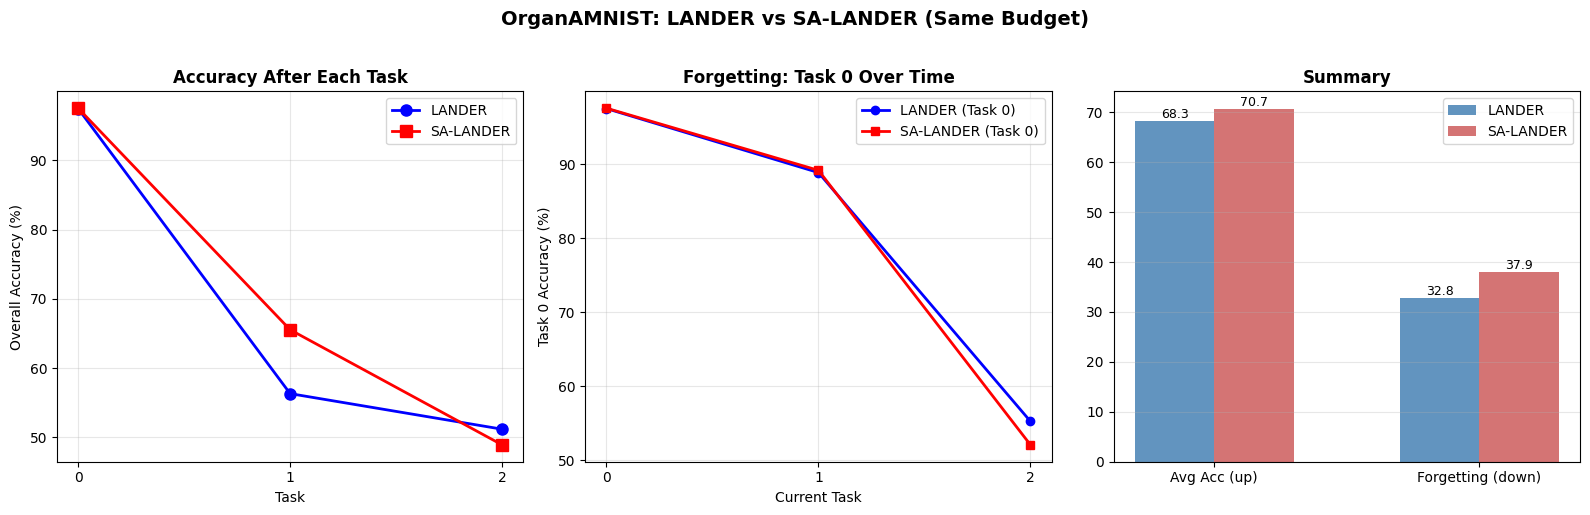

Saved to medical_results.png


In [12]:
# ============================================================
# Cell: Visualization
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
tasks = list(range(CFG['num_tasks']))

ax = axes[0]
ax.plot(tasks, lander_results['per_task_acc'], 'b-o', label='LANDER', linewidth=2, markersize=8)
ax.plot(tasks, sa_results['per_task_acc'], 'r-s', label='SA-LANDER', linewidth=2, markersize=8)
ax.set_xlabel('Task'); ax.set_ylabel('Overall Accuracy (%)')
ax.set_title('Accuracy After Each Task', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(tasks)

ax = axes[1]
if len(lander_results['task_acc_matrix']) >= 2:
    l0 = [lander_results['task_acc_matrix'][t][0] for t in range(CFG['num_tasks'])]
    s0 = [sa_results['task_acc_matrix'][t][0] for t in range(CFG['num_tasks'])]
    ax.plot(tasks, l0, 'b-o', label='LANDER (Task 0)', linewidth=2)
    ax.plot(tasks, s0, 'r-s', label='SA-LANDER (Task 0)', linewidth=2)
ax.set_xlabel('Current Task'); ax.set_ylabel('Task 0 Accuracy (%)')
ax.set_title('Forgetting: Task 0 Over Time', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3); ax.set_xticks(tasks)

ax = axes[2]
x = np.arange(2); w = 0.3
ax.bar(x-w/2, [l_avg, l_fgt], w, label='LANDER', color='steelblue', alpha=0.85)
ax.bar(x+w/2, [s_avg, s_fgt], w, label='SA-LANDER', color='indianred', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(['Avg Acc (up)', 'Forgetting (down)'])
ax.set_title('Summary', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for b in ax.containers:
    ax.bar_label(b, fmt='%.1f', fontsize=9)

plt.suptitle('OrganAMNIST: LANDER vs SA-LANDER (Same Budget)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('medical_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to medical_results.png")


## Analysis

### Why OrganAMNIST Is a Valid FCIL Benchmark
- **Federated relevance:** Hospitals cannot share patient CT scans — federated learning is the natural setting
- **Class-incremental relevance:** New organ types may be added to diagnostic models over time
- **Non-IID relevance:** Different hospitals specialize in different organs (naturally heterogeneous)

### What This Experiment Shows
Both methods run with **identical budget** (same rounds, clients, synthetic images). Any difference is purely from the adaptive per-class bounding radius. This eliminates the budget confound present in the CIFAR-100 comparison with paper LANDER numbers.

### Limitation
- CLIP was trained on natural images, not CT scans. The text embeddings capture semantic relationships (heart is closer to lung than to femur) but may not perfectly align with visual CT features.
- 11 classes with 3 tasks is a smaller-scale FCIL problem than CIFAR-100's 100 classes / 5 tasks.
